# Contexte

Au cours de notre année au sein de l'Université de Sherbrooke, nous avons été initiés à divers concepts fondamentaux lors du cours de Techniques d'apprentissage (IFT712). Ce cours nous a permis d'explorer et d'étudier plusieurs méthodes de classification, incluant les machines à vecteurs de support (SVM), les forêts aléatoires (Random Forest), les réseaux de neurones, les k-plus proches voisins (k-NN), la régression logistique, et d'autres algorithmes d'apprentissage supervisé.

Afin de clore cette session et de consolider nos connaissances théoriques et pratiques, nous avons pour projet final de mettre en application les concepts acquis en développant et en comparant six méthodes de classification différentes sur un jeu de données réel de notre choix. Ce projet vise à évaluer la performance de ces algorithmes, comprendre leurs forces et faiblesses respectives, et développer une expertise pratique en apprentissage automatique.

# Méthodologie de travail

Afin de réaliser ce projet, nous avons suivi une méthodologie de travail rigoureuse. En premier lieu, nous avons mis en place un  [**TRELLO**](https://trello.com/invite/b/693b2c8476833a31b8d5fda8/ATTI44ac34d643ef44d182e37f18d0572d93F5289FD2/ift712project) (Tableau de bord, Recherche, Expérimentation, Logique, Lecture, Organisation) pour structurer notre approche et assurer une progression méthodique tout au long du projet. Cet outil nous permet de suivre les différentes étapes du projet, de la recherche initiale à l'expérimentation et à l'analyse des résultats.

De plus, afin de communiquer efficacement et de collaborer de façon fluide, nous avons créé un groupe [**TEAMS**]() dédié au projet. Cet espace de travail collaboratif nous permet de partager des idées, des ressources, et de discuter des avancées du projet en temps réel.

Pour finir, nous avons mis en place un dépôt [**GITHUB**](https://github.com/) pour héberger notre code source, documenter nos travaux, et versionner nos différentes itérations. Ce dépôt facilite la collaboration entre les membres de l'équipe et assure une traçabilité claire des modifications apportées au code tout au long du projet.

# Jeu de données



## Présentation

Le jeu de données que nous avons choisi pour ce projet est **« NASA - Nearest Earth Objects »** disponible sur [Kaggle](https://www.kaggle.com/datasets/sameepvani/nasa-nearest-earth-objects). Ce jeu de données compile les informations relatives aux **objets proches de la Terre (NEO - Near-Earth Objects)** certifiés par la NASA, comprenant plus de 300 000 enregistrements concernant les astéroïdes et comètes détectés par les systèmes d'observation de la NASA. Les données ont été compilées à partir de sources officielles de la NASA, notamment le Centre d'Études des Objets Proches de la Terre (CNEOS) du Jet Propulsion Laboratory et le Minor Planet Center.

## Description

### Structure et contenu

Le jeu de données est structuré sous la forme de deux fichiers CSV avec une taille totale d'environ 7 Mo. Il contient des informations détaillées sur les objets proches de la Terre, notamment :

- **Paramètres orbitaux** : les distances relatives par rapport à la Terre, les vitesses orbitales et les vélocités absolues
- **Caractéristiques physiques** : les diamètres estimés des astéroïdes, les albédos et autres propriétés de surface
- **Approches rapprochées** : un résumé des approches les plus proches de la Terre et les dates de ces événements
- **Évaluation des risques** : les probabilités d'impact, les classifications de danger potentiel
- **Métadonnées de découverte** : les dates de découverte, les observatoires ayant effectué les observations initiales


Plus spécifiquement, le fichier principal `neo_data.csv` contient les colonnes suivantes :
- **`id`** : Identifiant unique attribué par le JPL (Jet Propulsion Laboratory) de la NASA.
- **`name`** : Le nom ou la désignation officielle de l'astéroïde (ex: "1999 RQ36")
- **`absolute_magnitude`** : Mesure de la luminosité intrinsèque. *Note* : Plus le chiffre est **petit**, plus l'objet est brillant et généralement gros.*
- **`est_diameter_min`** : Estimation basse du diamètre de l'astéroïde (en **km**).
- **`est_diameter_max`** : Estimation haute du diamètre de l'astéroïde (en **km**).
- **`relative_velocity`** (Vitesse relative) : Vitesse de l'astéroïde par rapport à la Terre lors de son passage (en **km/h**).
- **`miss_distance`** (Distance de passage) : La distance minimale entre l'astéroïde et la Terre (en **km**). C'est la donnée critique pour le risque d'impact.
- **`orbiting_body`** : L'astre autour duquel il gravite (ici, c'est généralement la **Terre** car on mesure l'approche terrestre).
- **`sentry_object`** : Indicateur (True/False) si l'objet est surveillé par le système "Sentry" de la NASA (système de détection de collisions futures).
- **`hazardous`** : **La variable à prédire (Target)**. Booléen (Vrai/Faux). Indique si l'astéroïde est classé comme **Potentiellement Dangereux** (PHA) selon sa taille et sa proximité.

Voici un aperçu global des typesdu jeu de données :

| Variable | Type de Données (Programmation) | Type de Variable (Statistique) |
| :--- | :--- | :--- |
| **`id`** | `Integer` (Entier) | Qualitatif Nominal |
| **`name`** | `String` (Chaîne de caractères) | Qualitatif Nominal |
| **`est_diameter_min`** | `Float` (Décimal) | Quantitatif Continu |
| **`est_diameter_max`** | `Float` (Décimal) | Quantitatif Continu |
| **`relative_velocity`** | `Float` (Décimal) | Quantitatif Continu |
| **`miss_distance`** | `Float` (Décimal) | Quantitatif Continu |
| **`orbiting_body`** | `String` (Chaîne de caractères) | Qualitatif Nominal |
| **`sentry_object`** | `Boolean` (Vrai/Faux) | Qualitatif Binaire |
| **`absolute_magnitude`**| `Float` (Décimal) | Quantitatif Continu |
| **`hazardous`** | `Boolean` (Vrai/Faux) | Qualitatif Binaire |

### Sources des données

Les données proviennent de deux sources institutionnelles majeures :

#### Centre for Near-Earth Object Studies (CNEOS)

Le **Centre for Near-Earth Object Studies (CNEOS)** du Jet Propulsion Laboratory (JPL) de la NASA constitue la source primaire des données. Le CNEOS joue un rôle central dans le calcul des orbites de très haute précision pour les NEOs, la prédiction des approches rapprochées futures, l'évaluation exhaustive des probabilités d'impact sur le siècle à venir, et l'archivage des paramètres orbitaux dans la JPL Small-Body Database (SBDB). Le CNEOS exploite également deux systèmes de surveillance automatisés de renommée mondiale : le système **Sentry**, qui analyse les catalogues d'astéroïdes pour identifier les candidats aux impacts potentiels sur 100 ans, et le système **Scout**, qui traite les découvertes potentielles en temps quasi-réel et peut identifier un impact potentiel en moins de 30 minutes suite à la détection initiale.

#### Minor Planet Center (MPC)

Le **Minor Planet Center (MPC)** de l'Union Astronomique Internationale gère le **Near-Earth Object Confirmation Page (NEOCP)**, où sont publiées les découvertes d'objets potentiels en temps quasi-réel. Le MPC collecte les observations reportées par les observateurs professionnels et amateurs du monde entier et maintient les catalogues officiels des astéroïdes et comètes.

### Instruments et Télescopes

La détection des objets proches de la Terre repose sur un écosystème sophistiqué d'instruments terrestres et spatiaux répartis à travers le monde :

#### Catalina Sky Survey (CSS)

Le **Catalina Sky Survey** est actuellement le programme de détection actif le plus productif, découvrant les NEO au taux le plus élevé. Il exploite un système de trois télescopes entièrement financés par la NASA : le **Mount Lemmon Observatory** (Arizona) doté d'un miroir de 1,5 mètre de diamètre et constituant l'installation la plus productive, le **Catalina Observatory** (Arizona), et le **Siding Spring Observatory** (Australie). Le système est conçu pour détecter les astéroïdes jusqu'à la magnitude 22 et traite les données en temps quasi-réel avec une latence d'environ 5 minutes après la dernière lecture d'image. Les découvertes sont validées par des observateurs experts et signalées au Minor Planet Center avec une latence typique d'environ 10 minutes.

#### Spacewatch Program

Le **programme Spacewatch** est en activité depuis plusieurs décennies avec le **Spacewatch Telescope** de 0,91 mètre sur Kitt Peak, équipé d'un détecteur CCD Tektronix 2048 x 2048. Le programme possède des capacités de suivi automatique d'objets se déplaçant entre 0,1 et 4 degrés par jour et a découvert plus de 700 NEOs avant sa transition vers un rôle de récupération et caractérisation.

#### WISE / NEOWISE

Le **Wide-field Infrared Survey Explorer (WISE)** est un télescope spatial infrarouge lancé en décembre 2009, fonctionnant avec un miroir infrarouge de 40 cm en orbite terrestre et des observations dans les bandes infrarouges à 3,4, 4,6, 12 et 22 μm. Après réactivation en 2013 sous le nom **NEOWISE**, la mission a découvert plus de 33 500 nouveaux astéroïdes et comètes et observe actuellement plus de 154 000 objets du système solaire. NEOWISE recherche les objets NEO de plus de 100 mètres de diamètre avec un albédo moyen de 0,14 et son exploitation coûte 5 millions de dollars par an pour son opération.

#### Autres Instruments

D'autres instruments complètent ce réseau de détection, notamment le **LONEOS (Lowell Observatory Near-Earth Object Search)**, le **Pan-STARRS (Panoramic Survey Telescope and Rapid Response System)**, et le **Large Synoptic Survey Telescope (LSST)** en développement, capable d'atteindre une magnitude limite de 25,1 pour détecter les NEO.

# Implémentation

Les six méthodes de classification seront implémentées et comparées sur ce jeu de données. Chaque méthode sera évaluée selon des métriques standard de performance, notamment la précision, le rappel, le F1-score et l'aire sous la courbe ROC. Une analyse comparative des résultats permettra d'identifier les forces et les faiblesses de chaque approche pour cette application spécifique.

## Import du jeu de données et prétraitement

Tout d'abord, nous importons le jeu de données afin d'avoir une vue d'ensemble de sa structure et de son contenu.

In [1]:
# Setup path
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project imports
from src.config import ConfigManager
from src.data import NEODataLoader, NEODataPreprocessor

# Initialize configuration
config = ConfigManager()
print(f"Configuration loaded from: {config.project_root / 'config.yaml'}")
print(f"Project root: {config.project_root}")

Configuration loaded from: C:\Users\robin\OneDrive\Documents\GitHub\COURS\IFT712_Project\config.yaml
Project root: C:\Users\robin\OneDrive\Documents\GitHub\COURS\IFT712_Project


In [2]:
# Load the dataset with the DataLoader
loader = NEODataLoader()
df = loader.load()

# Display data summary
loader.display_summary()
print("\nData preview:")
df.head()

✓ Data loaded: 90836 rows, 10 columns
  - Columns: ['id', 'name', 'est_diameter_min', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'orbiting_body', 'sentry_object', 'absolute_magnitude', 'hazardous']
  - Memory usage: 14.23 MB
  - Distribution of 'hazardous':
False    81996
    True      8840

Data preview:


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True


Une fois que nous avons une vue d'ensemble des caractéristiques du jeu de données, nous pouvons analyser la présence ou non de valeurs manquantes et le type de chaque caractéristique.

In [3]:
df.isna().sum()

id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

Nous remarquons que le jeu de données ne contient pas de valeurs manquantes, ce qui simplifie notre prétraitement.

Ensuite, nous analysons plus en détail les caractéristiques du jeu de données, plus précisément leurs types pour avoir une idée des transformations nécessaires avant de les utiliser dans nos modèles de classification.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90836 entries, 0 to 90835
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  90836 non-null  int64  
 1   name                90836 non-null  object 
 2   est_diameter_min    90836 non-null  float64
 3   est_diameter_max    90836 non-null  float64
 4   relative_velocity   90836 non-null  float64
 5   miss_distance       90836 non-null  float64
 6   orbiting_body       90836 non-null  object 
 7   sentry_object       90836 non-null  bool   
 8   absolute_magnitude  90836 non-null  float64
 9   hazardous           90836 non-null  bool   
dtypes: bool(2), float64(5), int64(1), object(2)
memory usage: 5.7+ MB


Nous nous occupons de transformer les colonnes booléennes en numériques (0 et 1) pour faciliter leur utilisation.

In [5]:
df.hazardous = [1 if val else 0 for val in df.hazardous]
df.sentry_object = [1 if val else 0 for val in df.sentry_object]

Ensuite, nous examinons les valeurs uniques des colonnes catégorielles pour décider comment les traiter.

In [6]:
cols = ['orbiting_body', 'sentry_object', 'hazardous']
print(" Valeurs uniques par colonne :")
print( "\t" + cols[0] + ': ' + str(df.orbiting_body.unique()) )
print( "\t" + cols[1] + ': ' + str(df.sentry_object.unique()) )
print( "\t" + cols[2] + ': ' + str(df.hazardous.unique()) )

 Valeurs uniques par colonne :
	orbiting_body: ['Earth']
	sentry_object: [0]
	hazardous: [0 1]


Nous remarquons que les colonnes **`orbiting_body`** et **`sentry_object`** sont invariantes, elles ne contiennent qu'une seule valeur unique. Nous décidons donc de les supprimer du jeu de données car elles n'apportent aucune information utile pour la modélisation. Egalement, la colonne **`id`** et **`name`** sont des identifiants uniques pour chaque enregistrement et ne contribuent pas à la prédiction de la variable cible. Nous les supprimons également.

In [7]:
df.drop(columns=['id', 'name', 'orbiting_body', 'sentry_object'], inplace=True)

Abordons maintenant la sélection des caractéristiques pertinentes pour nos modèles de classification. D'après nos recherches, les caractéristiques suivantes semblent particulièrement importantes pour évaluer le potentiel de dangerosité des objets proches de la Terre :

- **`est_diameter_min`**
- **`est_diameter_max`**
- **`relative_velocity`**
- **`miss_distance`**
- **`absolute_magnitude`**

Pour finir, nous ne prenons bien évidemment pas l'attribut **`hazardous`** en compte dans nos caractéristiques d'entrée pour nos modèles car il s'agit de notre variable cible.

Maintenant intéressons-nous aux variables corrélées du jeu de données. Pour cela, nous utilisons une matrice de corrélation pour visualiser les relations entre les différentes caractérisiques numériques.

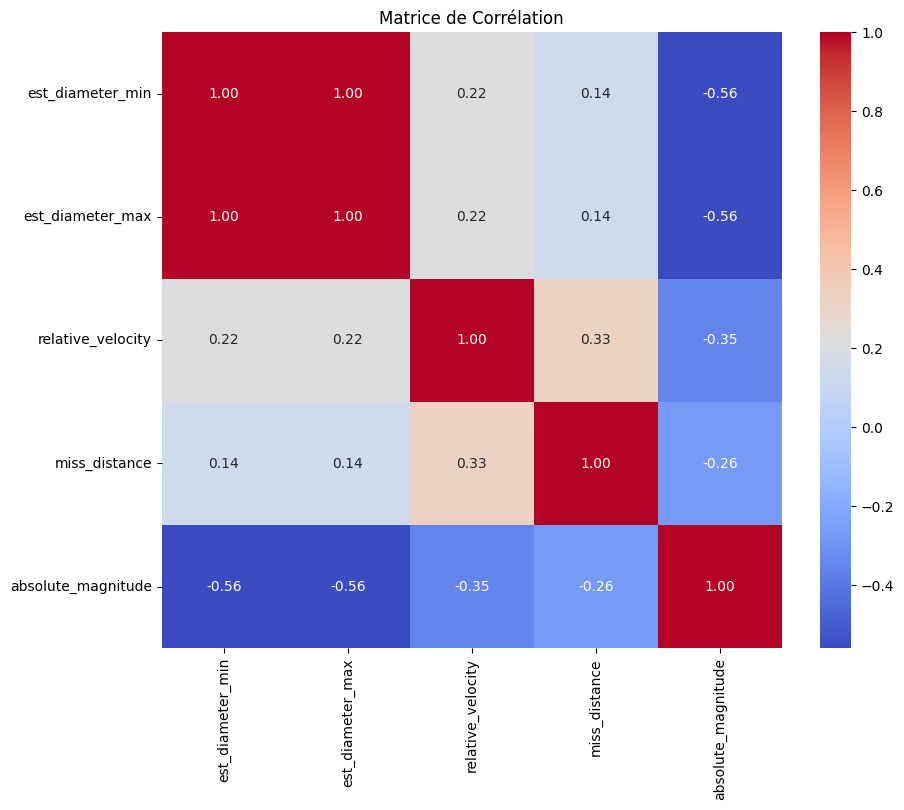

In [8]:
plt.figure(figsize=(10, 8))
# Get all numerical features
numeric_cols = config.get_param("preprocessing.numerical_features")
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation")
plt.show()

D'après la matrice de corrélation, nous pouvons observer que certaines caractéristiques présentent des corrélations significatives entre elles. Par exemple, les colonnes **`est_diameter_min`** et **`est_diameter_max`** sont **fortement corrélées** (exactement 1), ce qui est logique car elles réprésentent des estimations du diamètre de l'astéroïde.
Nous pouvons donc supprimer sans craintes l'une de ces deux colonnes pour éviter la redondance dans nos modèles. Nous choisissons de conserver **`est_diameter_max`** car elle représente la valeur maximale estimée du diamètre, ce qui peut être plus pertinent pour évaluer le potentiel de dangerosité.

In [9]:
df = df.drop(columns=['est_diameter_min'])

Ensuite, nous pouvons visualiser la distribution et outliers de chaque caractéristique numérique pour mieux comprendre leur comportement.

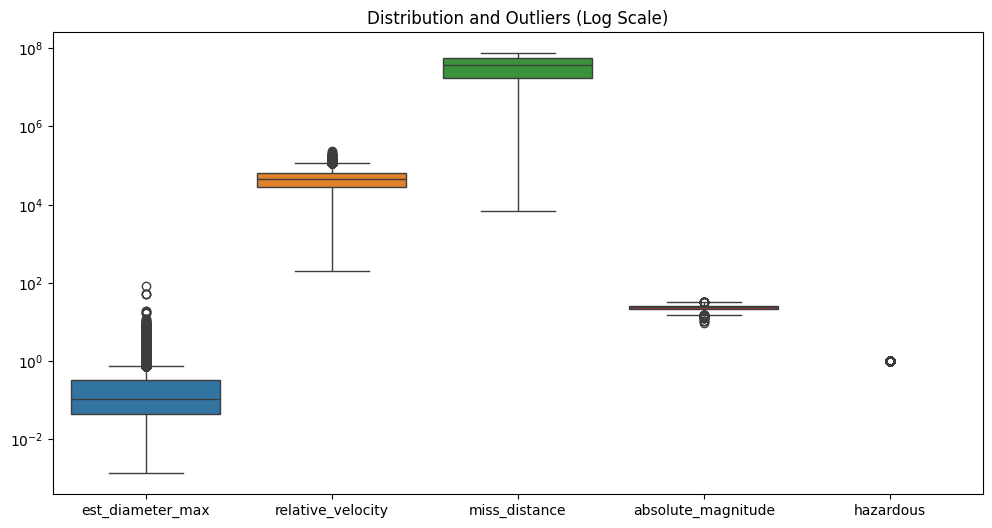

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.yscale('log')
plt.title("Distribution and Outliers (Log Scale)")
plt.show()

L'examen des boîtes à moustaches en échelle logarithmique révèle trois points cruciaux pour le prétraitement des données :

1.  **Colinéarité parfaite** : Les variables `est_diameter_min` et `est_diameter_max` présentent des distributions strictement identiques. Cette redondance confirme la nécessité de supprimer l'une des deux pour éviter la multicolinéarité.
2.  **Présence massive d'outliers** : Une forte asymétrie est visible pour les **diamètres** et la **vélocité**, avec de nombreuses valeurs aberrantes extrêmes vers le haut. Une standardisation classique (Z-score) serait biaisée ; une transformation logarithmique est nécessaire pour normaliser ces distributions.
3.  **Grande dispersion de la distance** : La variable `miss_distance` s'étend sur une plage immense (de $10^4$ à $10^8$). Bien qu'elle ait moins d'outliers isolés, cette **variance extrême** risque de dominer les calculs de distance (écrasement des autres variables). Elle nécessite donc aussi une transformation logarithmique avant la mise à l'échelle.

En prenant en compte ces observations, nous décidons d'appliquer une transformation logarithmique aux caractéristiques suivantes pour atténuer l'impact des outliers et normaliser les distributions :
- **`est_diameter_max`**
- **`relative_velocity`**
- **`miss_distance`**

Ainsi, dans le fichier **preprocessor**, nous transformons les données brutes en matrices prêtes pour l'entraînement des modèles. La fonction `preprocess` commence par isoler la variable cible (`hazardous`) des caractéristiques, puis divise le jeu de données en ensembles d'entraînement et de test afin de garantir une évaluation impartiale. Elle applique ensuite, via un `ColumnTransformer`, une transformation logarithmique (`np.log1p`) suivie d'une mise à l'échelle robuste (`RobustScaler`) sur les variables à forte asymétrie (*diameter*, *velocity*, *distance*), tandis que la magnitude absolue est uniquement normalisée, ce qui permet de réduire l'impact des valeurs aberrantes (*outliers*) et d'harmoniser les distributions avant l'apprentissage.

In [11]:
# Create and use the preprocessor
preprocessor = NEODataPreprocessor()

# Preprocess the data (split + normalization)
X_train, X_test, y_train, y_test = preprocessor.preprocess(df)

# Display split information
preprocessor.display_split_info()
preprocessor.display_normalization_stats()

print(f"\n Final dimensions:")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_test:  {X_test.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test:  {y_test.shape}")

✓ Data split:
  - Train: 72668 samples
  - Test:  18168 samples
  - Number of features: 4
  - Features: ['est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

 Normalization statistics:
  - X_train: min=-7.251, max=18.428, mean=-0.004, std=0.925
  - X_test:  min=-6.726, max=10.334, mean=-0.007, std=0.915
  → Data is centered around 0 with std ≈ 1

 Final dimensions:
  - X_train: (72668, 4)
  - X_test:  (18168, 4)
  - y_train: (72668,)
  - y_test:  (18168,)


L'étape de validation du pipeline de données confirme une préparation optimale pour les futurs modèles de classification. Avec un échantillon d'entraînement de **72 668** observations et un ensemble de test de **18 168**, la séparation des données respecte strictement le ratio **80/20** défini dans la configuration. Le processus de sélection a permis d'isoler quatre caractéristiques fondamentales : le diamètre maximal estimé, la vitesse relative, la distance de rapprochement et la magnitude absolue. Cette réduction dimensionnelle, combinée à la suppression des identifiants et des variables invariantes, garantit un modèle focalisé sur les prédicteurs à fort impact.

L'application du `RobustScaler` couplée à une transformation logarithmique montre une efficacité remarquable sur les distributions initialement asymétriques du dataset NASA. Les statistiques post-traitement révèlent une médiane centrée exactement à 0.000 et une moyenne de -0.004, témoignant d'une distribution désormais symétrique. L'écart-type stabilisé autour de 0.925 assure que toutes les variables partagent une échelle comparable. Cette normalisation est cruciale pour la stabilité des coefficients du classifieur par moindres carrés (Ridge) et permet d'éviter que les caractéristiques à forte variance, comme la distance de rapprochement, ne dominent artificiellement le processus d'apprentissage.

Suite à l'exécution du pipeline de prétraitement, il est essentiel de valider visuellement l'impact des transformations appliquées sur nos variables explicatives.

Les graphiques ci-dessous comparent les distributions **avant** (données brutes) et **après** transformation (logarithme et/ou mise à l'échelle). L'objectif est de confirmer que l'application de la fonction logarithmique (`np.log1p`) a bien permis de réduire l'asymétrie (*skewness*) des variables comme le diamètre ou la vélocité, et que le `RobustScaler` a uniformisé les plages de valeurs tout en gérant les valeurs aberrantes.

Vérification de l'effet du prétraitement (Log + Scaling) :


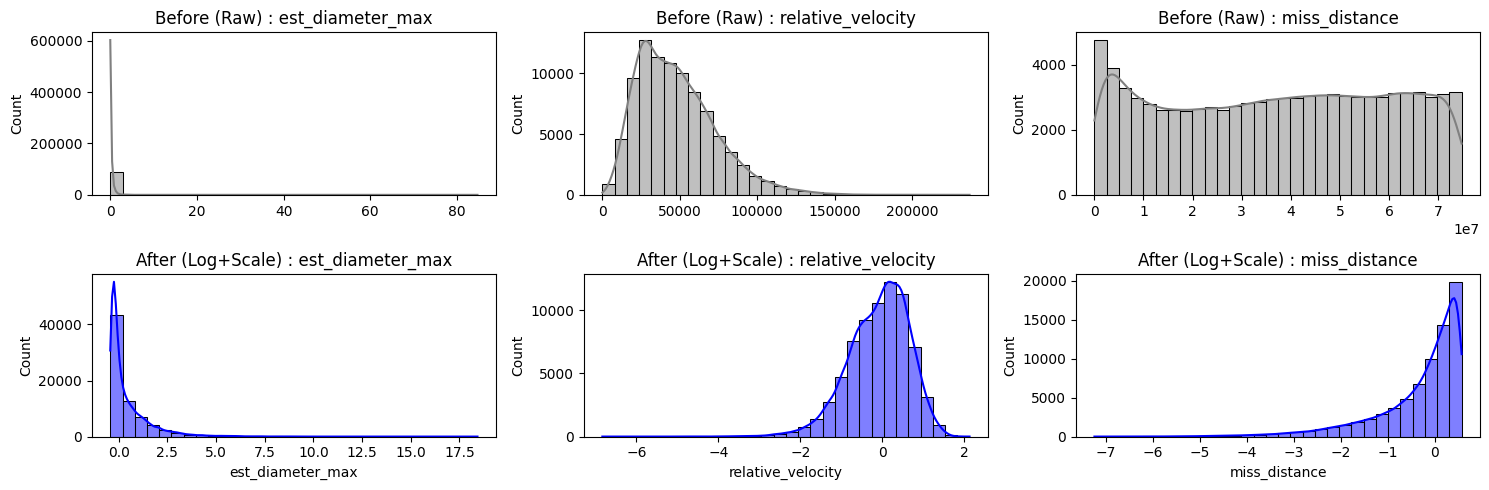

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = preprocessor.get_feature_names()
log_features = preprocessor.log_features

X_train_df = pd.DataFrame(X_train, columns=feature_names)

print("Vérification de l'effet du prétraitement (Log + Scaling) :")

plt.figure(figsize=(15, 5))
for i, col in enumerate(log_features):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], bins=30, kde=True, color='gray')
    plt.title(f"Before (Raw) : {col}")
    plt.xlabel("")
    
    plt.subplot(2, 3, i+4)
    sns.histplot(X_train_df[col], bins=30, kde=True, color='blue')
    plt.title(f"After (Log+Scale) : {col}")
    
plt.tight_layout()
plt.show()


Class Distribution Analysis (Hazardous)
           Train Count  Train %  Test Count  Test %
hazardous                                          
0                65596    90.27       16400   90.27
1                 7072     9.73        1768    9.73


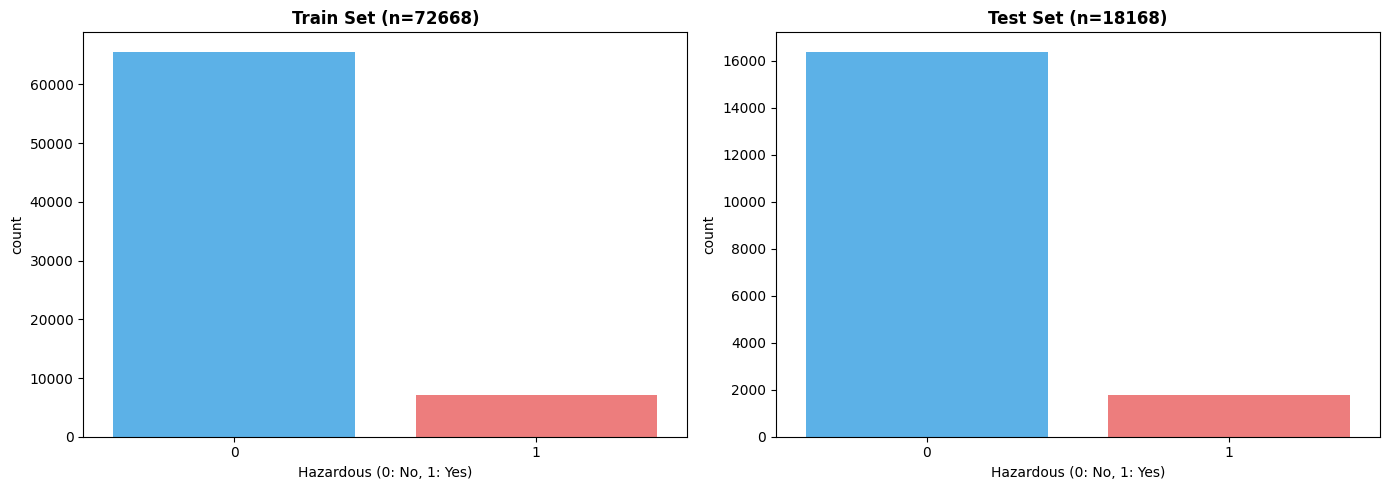

In [14]:
from src.utils.visualisation_utils import VisualizationUtils

VisualizationUtils.plot_class_distribution(y_train, y_test, target_name="Hazardous")

L'analyse de la répartition de la variable cible hazardous met en évidence un **déséquilibre prononcé**, caractéristique des enjeux de détection d'objets géocroiseurs. Avec seulement `9.73%` d'objets classés comme dangereux, le dataset présente un ratio d'environ 9:1. La vérification confirme que ce ratio est préservé de manière quasi identique entre les ensembles d'entraînement et de test grâce à la stratification. Cette structure justifie l'implémentation de stratégies compensatoires, telles que l'utilisation de poids de classe (class_weight: balanced), pour forcer le modèle à accorder une importance accrue à la détection de la classe minoritaire.

# Résultats

# Conclusions